# South Barnegat Bay Onshore Wind Model Prediction with the Use of Long Short-Term Memory Neural Networks - Graphing

In [740]:
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

In [741]:
import matplotlib as mpl
#mpl.rcParams["font.family"] = "sans-serif"
#mpl.rcParams["font.sans-serif"] = ["Times New Roman"]  # or another installed font
#mpl.rcParams["font.size"] = 12
mpl.rcdefaults()

In [742]:
myfont = {'fontname':'Georgia'}

In [743]:
#Open data as csv
data = pd.read_csv("csv/CLEAN.csv")

#Convert to datetime
#Convert data into Date time and create date filter
data['Date'] = pd.to_datetime(data['Date'])
data['Date'] = data['Date'] + pd.to_timedelta(data["Hr"], unit="h")
data.drop('Hr', axis=1, inplace=True)

In [744]:
raw = pd.read_csv("csv/RAW_data.csv")

#Convert to datetime
#Convert data into Date time and create date filter
raw['Date'] = pd.to_datetime(raw['Date'])
raw['Date'] = raw['Date'] + pd.to_timedelta(raw["Hr"], unit="h")
raw.drop('Hr', axis=1, inplace=True)

In [745]:
#Open data as csv
data_p = pd.read_csv("csv/all_predictions.csv")

#convert to datetime
data_p['Date'] = pd.to_datetime(data_p['Date'])
print(data_p['Date'].dtype)

datetime64[ns]


In [746]:
data.head()

,Date,Mainland Air Temp,Humidity (%),Direction (A),Wind Speed (A),Gusting,Atmospheric Pressure (IN),Precipitation Rate,Bay Temp,Salinity,LBI Air Temp,Ocean Temp,Onshore,upwelling_flag
0,2025-06-02 00:00:00,13.9,68.0,10,3.8,6.0,29.86,0.00,17.47,27.70,17.8,14.3,0,0
1,2025-06-02 01:00:00,13.6,74.0,12,4.0,6.2,29.88,0.00,17.49,28.20,17.5,14.2,0,0
2,2025-06-02 02:00:00,12.7,78.0,11,3.0,5.4,29.88,0.01,17.27,27.93,16.2,14.2,0,0
3,2025-06-02 03:00:00,11.3,84.0,12,2.7,6.1,29.88,0.00,17.26,28.41,14.9,14.2,0,0
4,2025-06-02 04:00:00,10.3,87.0,13,2.0,3.8,29.89,0.00,16.82,28.42,13.7,14.2,0,0


In [747]:
data_p.head()

,Date,Mainland Air Temp,Humidity (%),Direction (A),Wind Speed (A),Gusting,Atmospheric Pressure (IN),Precipitation Rate,Bay Temp,Salinity,LBI Air Temp,Ocean Temp,Onshore,upwelling_flag,upwelling_pred_naive,onshore_pred_direction,wind_direction_pred_naive,wind_speed_pred_linear,wind_gust_pred_linear,Wind_pred_warning
0,2025-06-02 00:00:00,13.9,68.0,10,3.8,6.0,29.86,0.00,17.47,27.70,17.8,14.3,0,0,NaN,NaN,NaN,NaN,NaN,False
1,2025-06-02 01:00:00,13.6,74.0,12,4.0,6.2,29.88,0.00,17.49,28.20,17.5,14.2,0,0,NaN,NaN,NaN,NaN,NaN,False
2,2025-06-02 02:00:00,12.7,78.0,11,3.0,5.4,29.88,0.01,17.27,27.93,16.2,14.2,0,0,NaN,NaN,NaN,NaN,NaN,False
3,2025-06-02 03:00:00,11.3,84.0,12,2.7,6.1,29.88,0.00,17.26,28.41,14.9,14.2,0,0,NaN,NaN,NaN,NaN,NaN,False
4,2025-06-02 04:00:00,10.3,87.0,13,2.0,3.8,29.89,0.00,16.82,28.42,13.7,14.2,0,0,NaN,NaN,NaN,NaN,NaN,False


### Plot of all variables (Actual)

Text(0, 0.5, 'Air Temperature (C)')

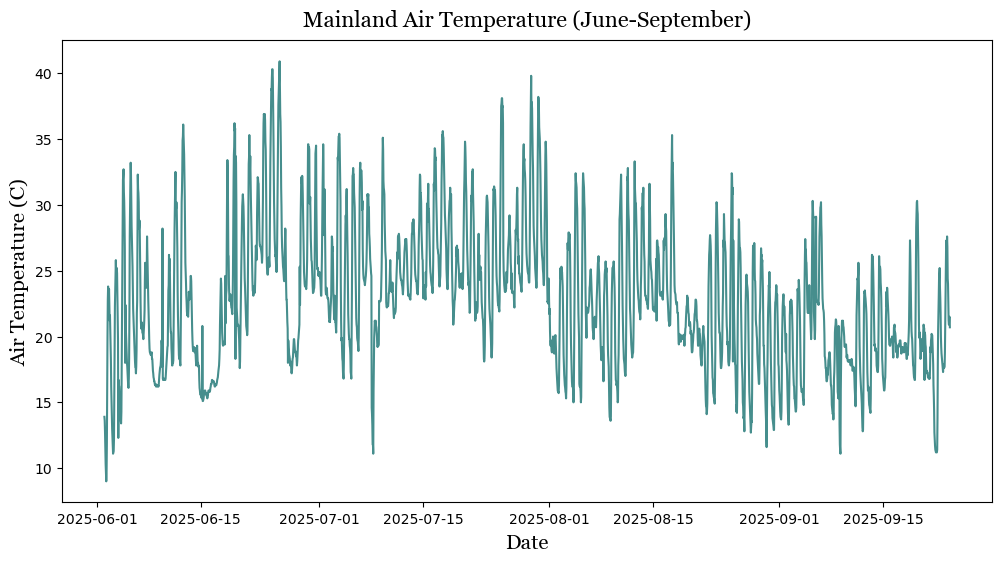

In [748]:
#Plot 1 - Mainland Air Temp

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Mainland Air Temp'], label='Mainland Air Temperature', color='#468e8d')
plt.title("Mainland Air Temperature (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel('Date', labelpad=5, **myfont, fontsize=15)
plt.ylabel('Air Temperature (C)', **myfont, fontsize=15)

Text(0, 0.5, 'Himidity (%)')

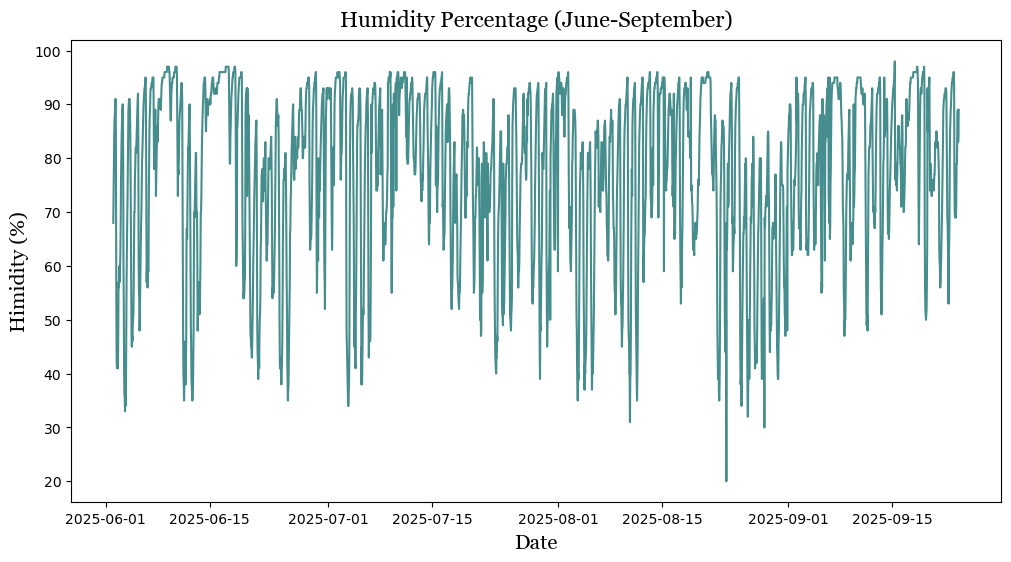

In [749]:
#Plot 2 - Humidity (%)

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Humidity (%)'], label='Humidity (%)', color='#468e8d')
plt.title("Humidity Percentage (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel('Date', labelpad=5, **myfont, fontsize=15)
plt.ylabel('Himidity (%)', **myfont, fontsize=15)

Text(0, 0.5, 'Direction')

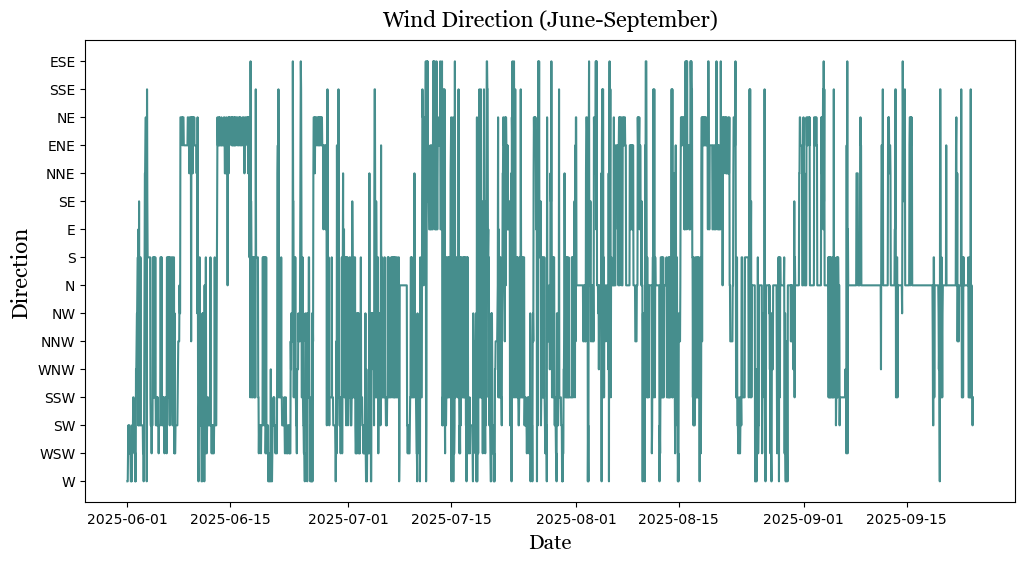

In [750]:
#Plot 3 - Direction over Time? (Not really sure what to do with this one)

plt.figure(figsize=(12,6))
plt.plot(raw['Date'], raw['Direction (A)'], label='Direction', color='#468e8d')
plt.title("Wind Direction (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel('Date', labelpad=5, **myfont, fontsize=15)
plt.ylabel('Direction', **myfont, fontsize=16)

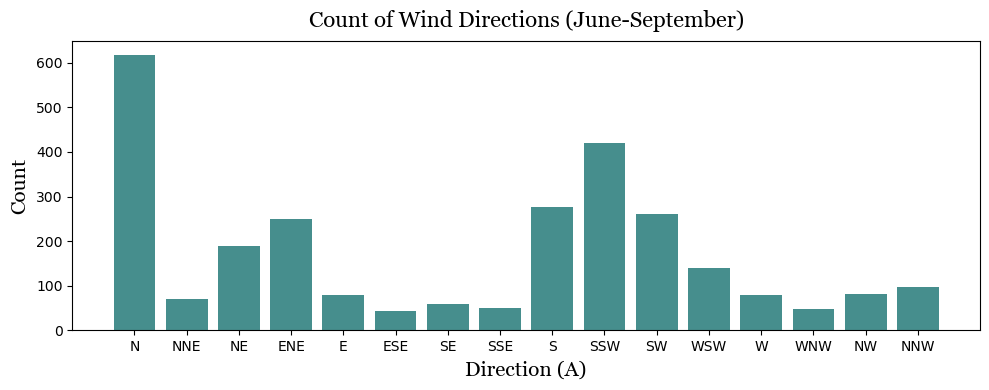

In [751]:
#Plot 4 - Direction Counts

counts = raw["Direction (A)"].value_counts()

order = ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE",
         "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"]

labels = order
values = [counts.get(d, 0) for d in order]

plt.figure(figsize=(10, 4))
plt.bar(labels, values, label='Directions', color='#468e8d')
plt.title("Count of Wind Directions (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel("Direction (A)", labelpad=5, **myfont, fontsize=15)
plt.ylabel("Count", labelpad=5, **myfont, fontsize=15)
plt.tight_layout()

Text(0, 0.5, 'Wind Speed (mph)')

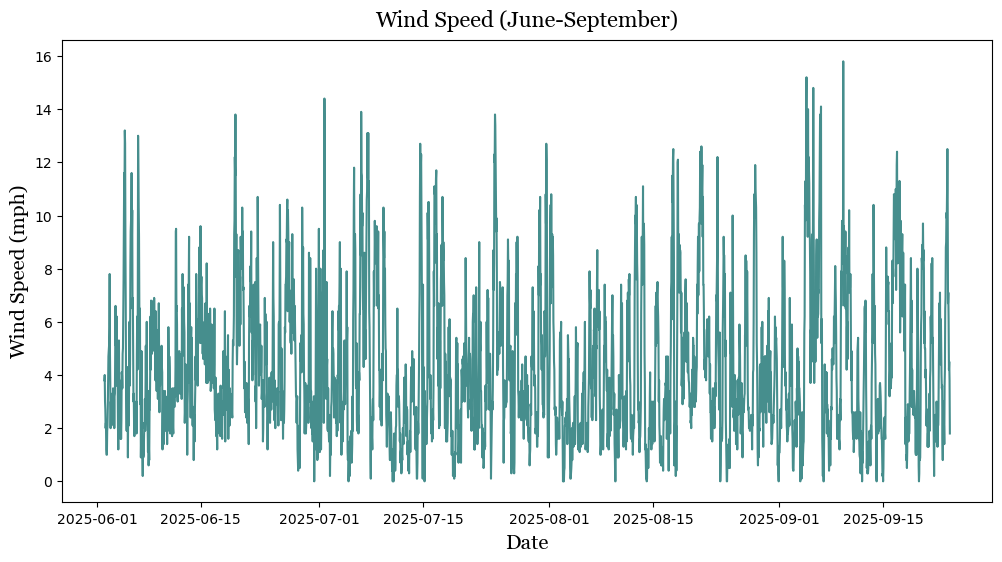

In [752]:
#Plot 5 - Wind Speed 

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Wind Speed (A)'], label='Wind Speed', color='#468e8d')
plt.title("Wind Speed (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel('Date', labelpad=5, **myfont, fontsize=15)
plt.ylabel('Wind Speed (mph)', **myfont, fontsize=15)

Text(0, 0.5, 'Wind Gusting Speed (mph)')

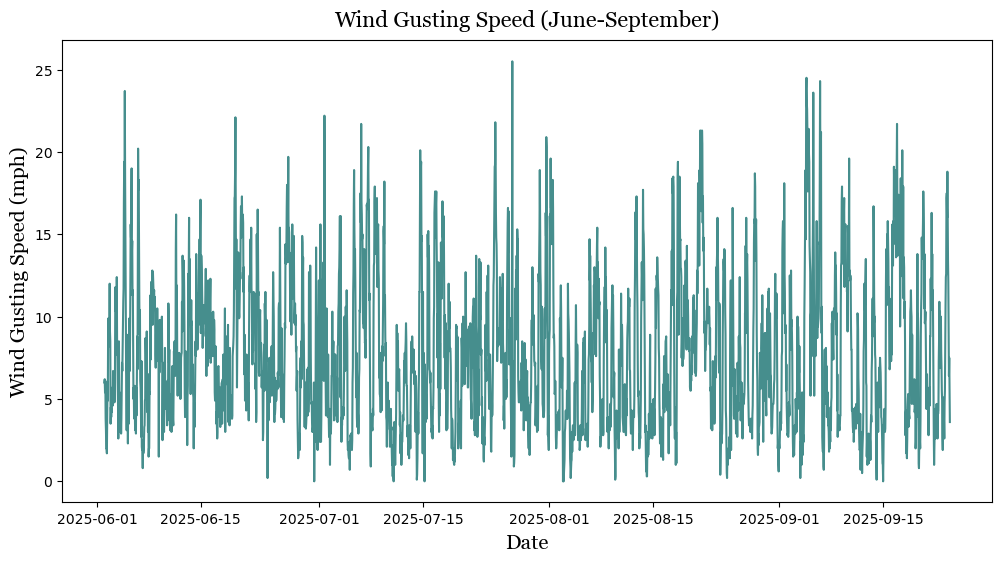

In [753]:
#Plot 6 - Wind Gust Speed 

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Gusting'], label='Wind Gust Speed', color='#468e8d')
plt.title("Wind Gusting Speed (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel('Date', labelpad=5, **myfont, fontsize=15)
plt.ylabel('Wind Gusting Speed (mph)', **myfont, fontsize=15)

Text(0, 0.5, 'Atmospheric Pressure (IN)')

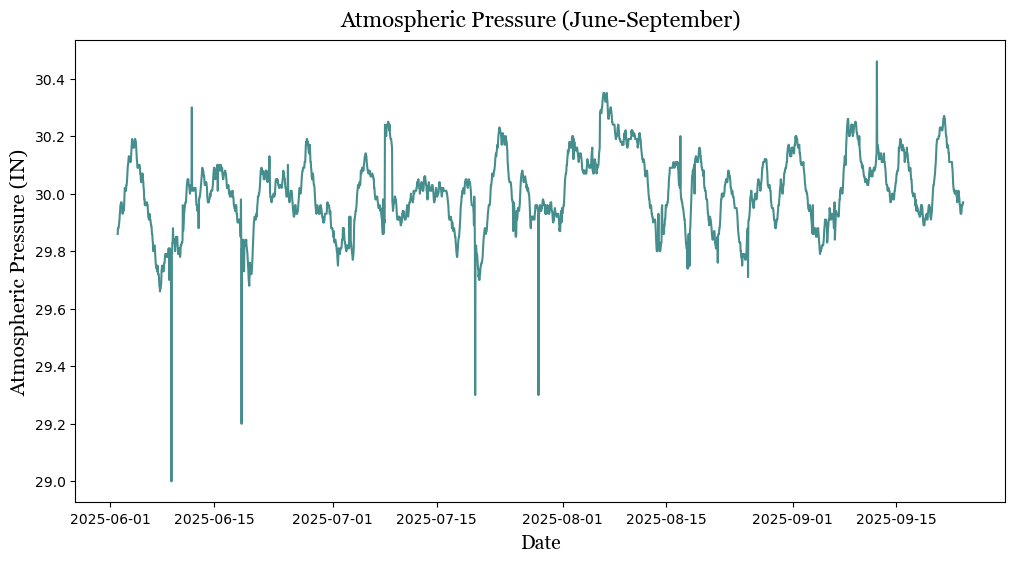

In [754]:
#Plot 7 - Atomspheric Pressure

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Atmospheric Pressure (IN)'], label='Atmospheric Pressure', color='#468e8d')
plt.title("Atmospheric Pressure (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel('Date', labelpad=5, **myfont, fontsize=14)
plt.ylabel('Atmospheric Pressure (IN)', **myfont, fontsize=15)

Text(0, 0.5, 'Precipitation Rate (IN)')

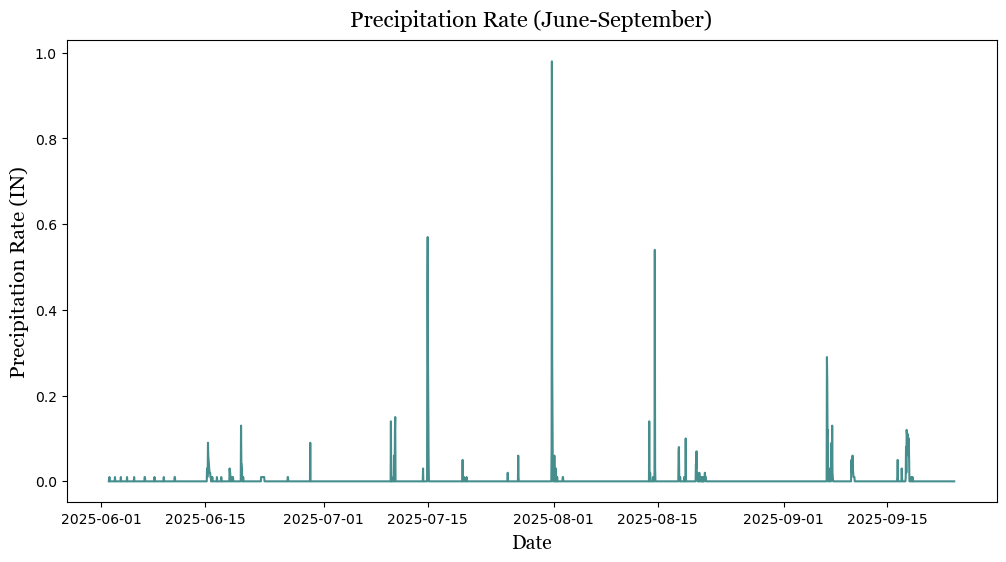

In [755]:
#Plot 8 - Precipitation

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Precipitation Rate'], label='Precipitation Rate', color='#468e8d')
plt.title("Precipitation Rate (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel('Date', labelpad=5, **myfont, fontsize=14)
plt.ylabel('Precipitation Rate (IN)', **myfont, fontsize=15)

Text(0, 0.5, 'Bay Temperature (C)')

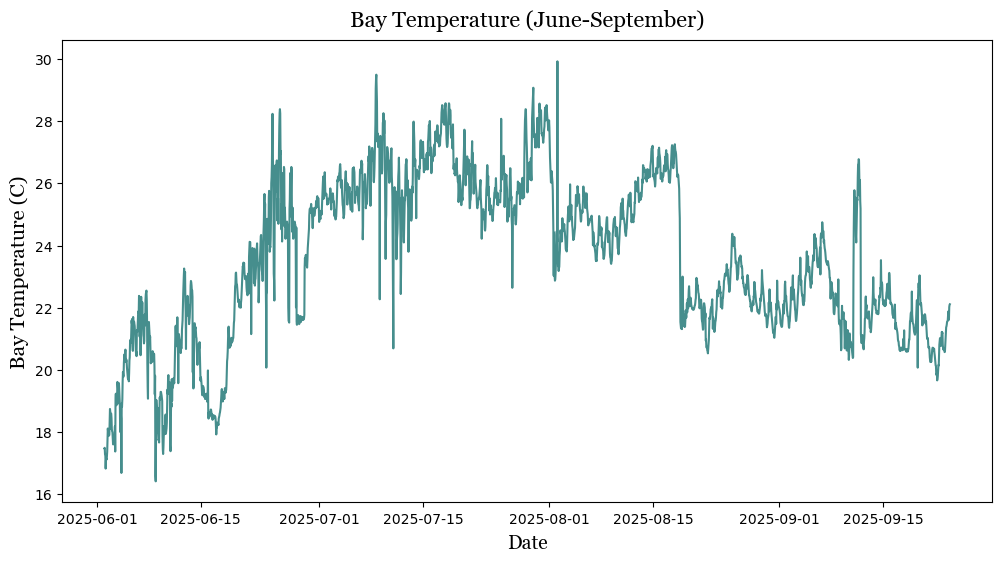

In [756]:
#Plot 9 - Bay Temp
plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Bay Temp'], label='Bay Temperature', color='#468e8d')
plt.title("Bay Temperature (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel('Date', labelpad=5, **myfont, fontsize=14)
plt.ylabel('Bay Temperature (C)', **myfont, fontsize=15)

Text(0, 0.5, 'Bay Salinity (PPT)')

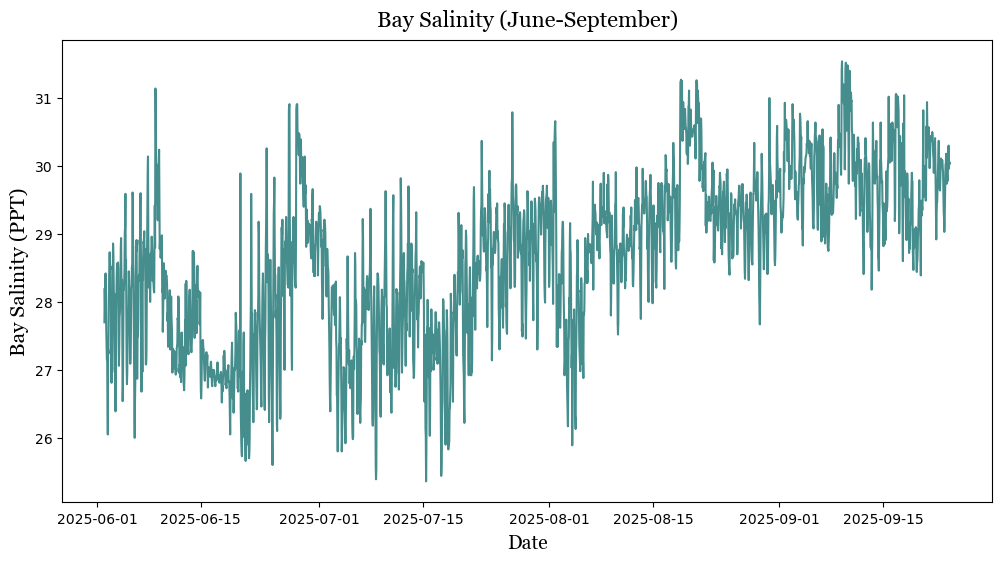

In [757]:
#Plot 10 - Salinity

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Salinity'], label='Salinity', color='#468e8d')
plt.title("Bay Salinity (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel('Date', labelpad=5, **myfont, fontsize=14)
plt.ylabel('Bay Salinity (PPT)', **myfont, fontsize=15)

Text(0, 0.5, 'LBI Air Temperature (C)')

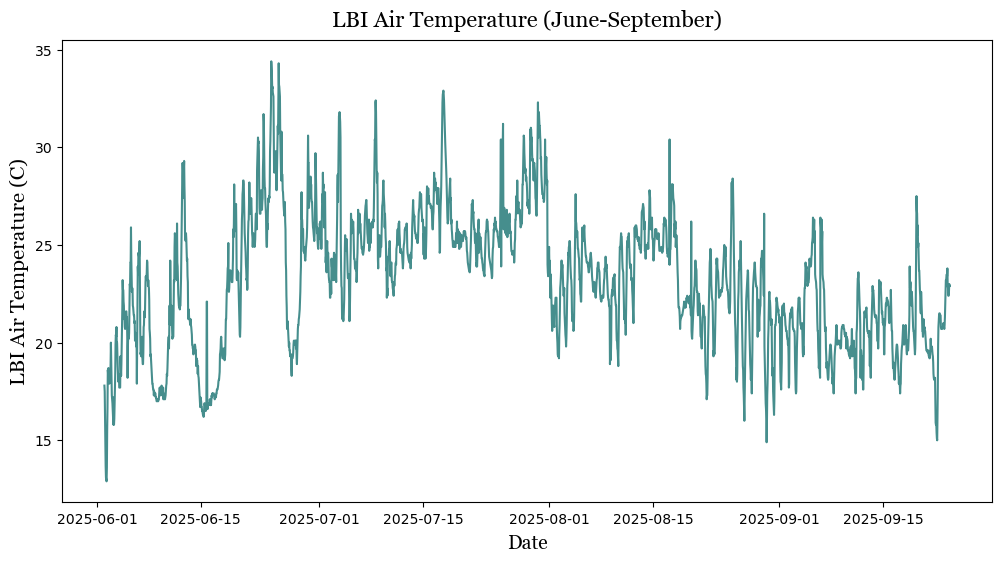

In [758]:
#Plot 11 - LBI Air Temp

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['LBI Air Temp'], label='LBI Air Temperature', color='#468e8d')
plt.title("LBI Air Temperature (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel('Date', labelpad=5, **myfont, fontsize=14)
plt.ylabel('LBI Air Temperature (C)', **myfont, fontsize=15)

Text(0, 0.5, 'Ocean Temperature (C)')

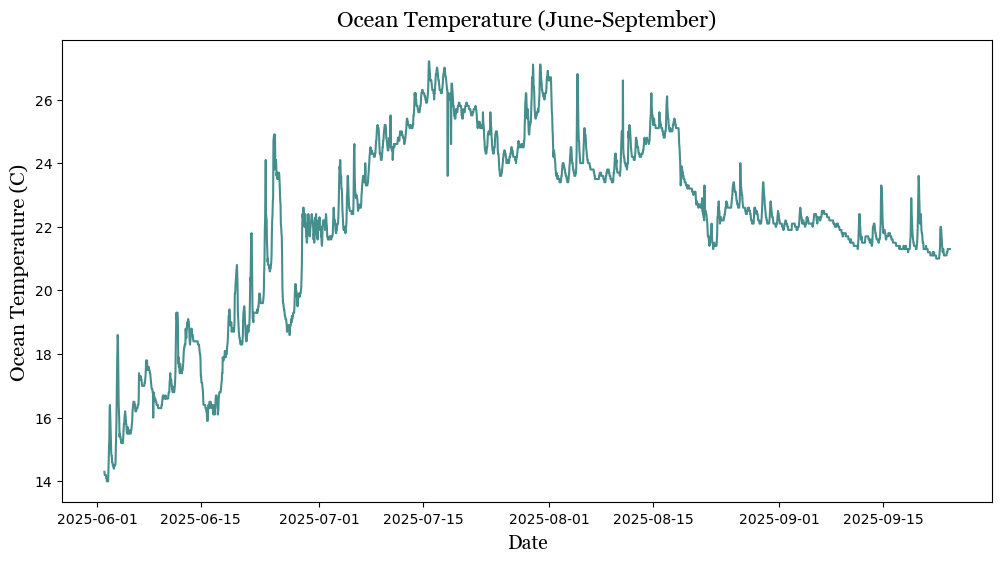

In [759]:
#Plot 12 - Ocean Temp

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Ocean Temp'], label='Ocean Temperature', color='#468e8d')
plt.title("Ocean Temperature (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel('Date', labelpad=5, **myfont, fontsize=14)
plt.ylabel('Ocean Temperature (C)', **myfont, fontsize=15)

Text(0, 0.5, 'Onshore Winds (Yes or No)')

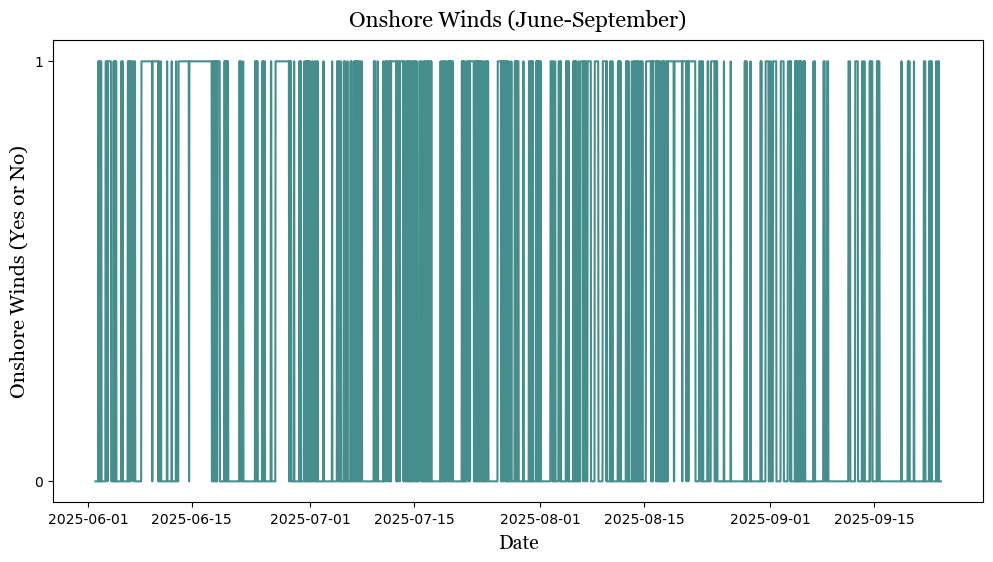

In [760]:
#Plot 13 - Onshore

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Onshore'], label='Onshore Winds', color='#468e8d')
plt.title("Onshore Winds (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel('Date', labelpad=5, **myfont, fontsize=14)
plt.yticks([0, 1])
plt.ylabel('Onshore Winds (Yes or No)', **myfont, fontsize=15)

### Actual VS Predicted Data

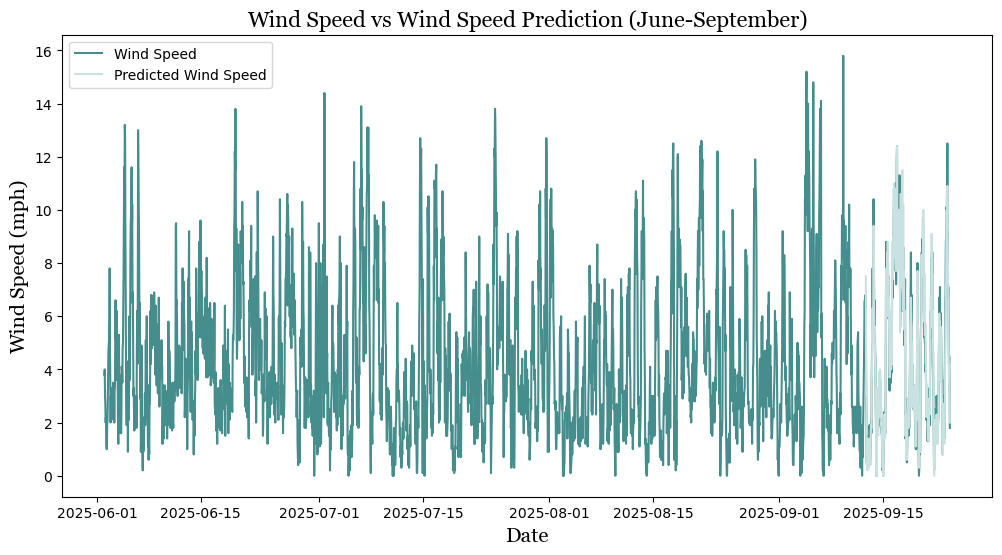

In [761]:
#Plot 14 - Wind Speed VS Wind Speed Prediction


plt.figure(figsize=(12,6))
plt.plot(data_p['Date'], data_p['Wind Speed (A)'], label='Wind Speed', color='#468e8d')
plt.plot(data_p['Date'], data_p['wind_speed_pred_linear'], label='Predicted Wind Speed', color='#c8e1e1')
plt.title("Wind Speed vs Wind Speed Prediction (June-September)", **myfont, fontsize=16)
plt.xlabel('Date', **myfont, fontsize=15)
plt.ylabel('Wind Speed (mph)', **myfont, fontsize=15)
plt.legend()

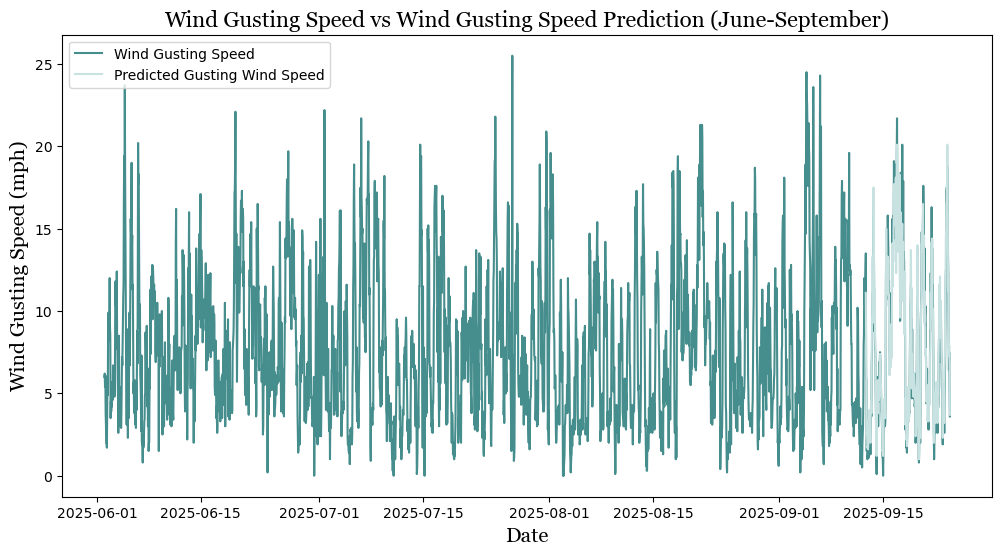

In [762]:
#Plot 15 - Wind Gust Speed VS Wind Gust Speed Prediction


plt.figure(figsize=(12,6))
plt.plot(data_p['Date'], data_p['Gusting'], label='Wind Gusting Speed', color='#468e8d')
plt.plot(data_p['Date'], data_p['wind_gust_pred_linear'], label='Predicted Gusting Wind Speed', color='#c8e1e1')
plt.title("Wind Gusting Speed vs Wind Gusting Speed Prediction (June-September)", **myfont, fontsize=16)
plt.xlabel('Date', **myfont, fontsize=15)
plt.ylabel('Wind Gusting Speed (mph)', **myfont, fontsize=15)
plt.legend()


In [763]:
print(data_p['wind_direction_pred_naive'].dtype)

float64


In [764]:
#Convert predicted directions back to labels
#replace the direction column with the corresponding degree values
direction_map = { 0: 'N', 1: 'NNE', 2: 'NE', 3: 'ENE', 4: 'E', 5: 'ESE', 6: 'SE', 7: 'SSE',
8: 'S', 9: 'SSW', 10: 'SW', 11: 'WSW', 12: 'W', 13: 'WNW', 14: 'NW', 15: 'NNW'
}

data_p['Direction (A)'] = data_p['Direction (A)'].replace(direction_map).infer_objects(copy = False)

data_p['wind_direction_pred_label'] = data_p['wind_direction_pred_naive'].map(direction_map)
data_p.tail()

,Date,Mainland Air Temp,Humidity (%),Direction (A),Wind Speed (A),Gusting,Atmospheric Pressure (IN),Precipitation Rate,Bay Temp,Salinity,...,Ocean Temp,Onshore,upwelling_flag,upwelling_pred_naive,onshore_pred_direction,wind_direction_pred_naive,wind_speed_pred_linear,wind_gust_pred_linear,Wind_pred_warning,wind_direction_pred_label
2732,2025-09-23 20:00:00,21.2,88.0,N,6.0,9.1,29.96,0.0,21.84,30.30,...,21.3,0,0,0.0,0.0,0.0,5.2,10.3,True,N
2733,2025-09-23 21:00:00,20.9,89.0,SSW,4.2,6.4,29.96,0.0,21.61,29.96,...,21.3,0,0,0.0,0.0,0.0,3.6,7.3,False,N
2734,2025-09-23 22:00:00,21.4,83.0,SSW,4.5,7.5,29.96,0.0,22.02,30.06,...,21.3,0,0,0.0,0.0,9.0,4.2,7.9,False,SSW
2735,2025-09-23 23:00:00,21.5,84.0,SW,3.8,5.3,29.97,0.0,22.09,30.03,...,21.3,0,0,0.0,0.0,9.0,3.0,6.8,False,SSW
2736,2025-09-24 00:00:00,20.7,89.0,SSW,1.8,3.6,29.97,0.0,22.11,30.04,...,21.3,0,0,0.0,0.0,10.0,2.0,3.7,False,SW


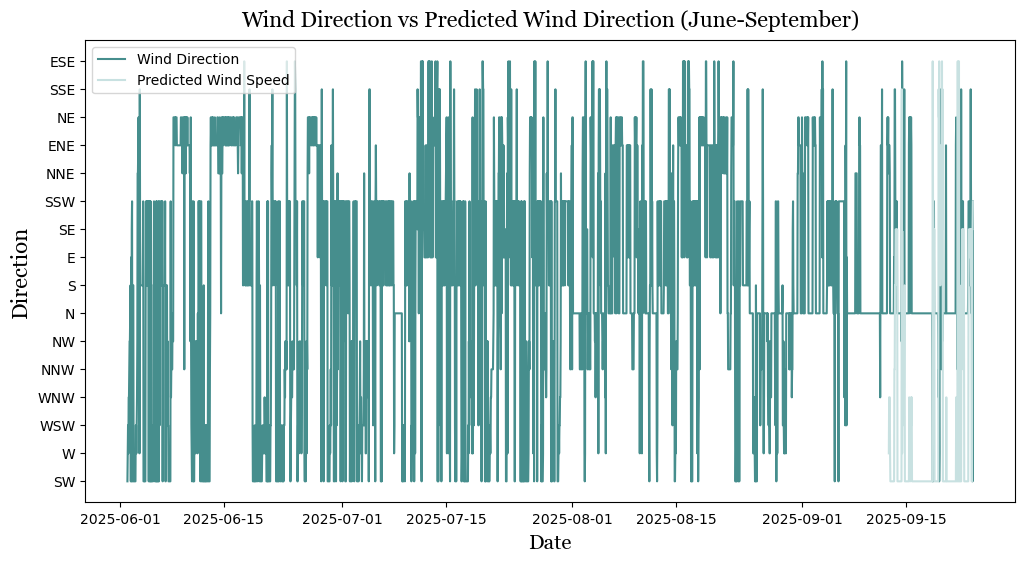

In [765]:
#Plot 16 - Direction vs Predicted Directionover Time? (Not really sure what to do with this one)

plt.figure(figsize=(12,6))
plt.plot(data_p['Date'], data_p['Direction (A)'], label='Wind Direction', color='#468e8d')
plt.plot(data_p['Date'], data_p['wind_direction_pred_naive'], label='Predicted Wind Speed', color='#c8e1e1')
plt.title("Wind Direction vs Predicted Wind Direction (June-September)", **myfont, pad=10, fontsize=16)
plt.xlabel('Date', labelpad=5, **myfont, fontsize=15)
plt.ylabel('Direction', **myfont, fontsize=16)
plt.legend()

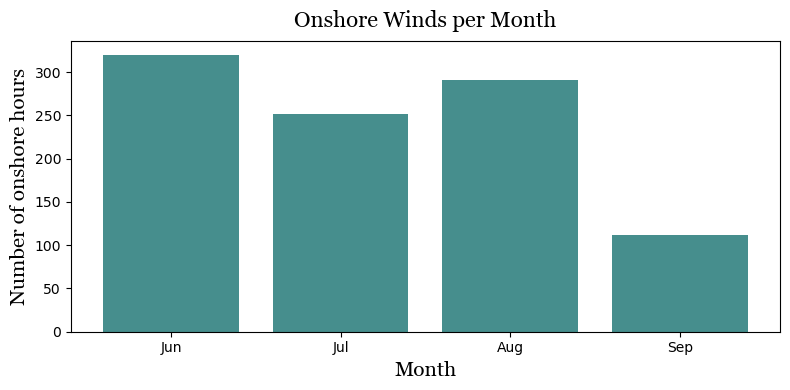

In [767]:
#Plot 18 - Onshore Winds per Month
# count onshore winds per month
monthly_counts = (
    data_p[data_p['Onshore'] == 1]           
      .groupby(data_p['Date'].dt.to_period('M'))  
      ['Onshore'].count()                   
)
monthly_counts.index = monthly_counts.index.to_timestamp()
months = monthly_counts.index.strftime('%b')

plt.figure(figsize=(8,4))
plt.bar(months, monthly_counts.values, color='#468e8d')
plt.title('Onshore Winds per Month', **myfont, pad=10, fontsize=16)
plt.xlabel('Month', **myfont, fontsize=15)
plt.ylabel('Number of onshore hours', **myfont, fontsize=15)

plt.tight_layout()
plt.show()

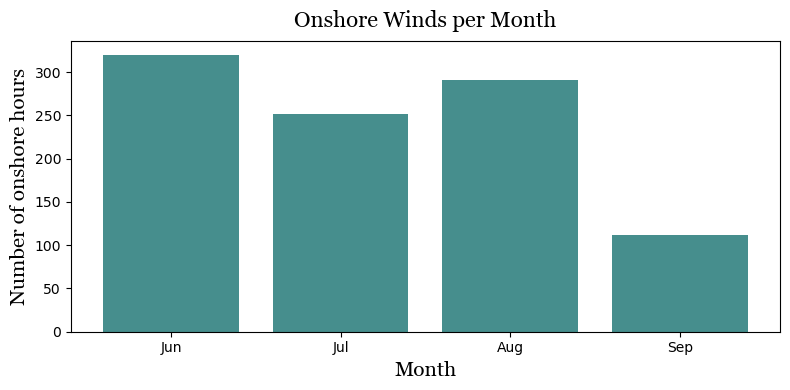

In [768]:
#Plot 19 - Predicted Onshore Winds per Month

# count onshore winds per month
monthly_counts = (
    data_p[data_p['Onshore'] == 1]           
      .groupby(data_p['Date'].dt.to_period('M'))  
      ['Onshore'].count()                   
)
monthly_counts.index = monthly_counts.index.to_timestamp()
months = monthly_counts.index.strftime('%b')

plt.figure(figsize=(8,4))
plt.bar(months, monthly_counts.values, color='#468e8d')
plt.title('Onshore Winds per Month', **myfont, pad=10, fontsize=16)
plt.xlabel('Month', **myfont, fontsize=15)
plt.ylabel('Number of onshore hours', **myfont, fontsize=15)

plt.tight_layout()
plt.show()